# 8 Conclusion

Aggregate every candidate produced upstream into a single validation-F1 leaderboard, commit one champion, and judge that champion once on the held-out test partition. The output is `data/final_model.joblib` (the deployable bundle) plus the registered model version on the MLflow Model Registry with the `@champion` alias the inference API resolves at serve time.

**Why selection earns its own notebook.** Selection is the only place in the pipeline that touches `X_test`, and the discipline of touching the test set exactly once is structural rather than stylistic. Every upstream stage scores candidates on `X_val`. Aggregating those validation scores, picking a winner by a single committed rule, and only then evaluating the winner on `X_test` is the only way to produce a generalisation number that is not biased by repeated test-set queries during development.

**Structure of every section that follows.**

1. A "what we are doing and why" framing.
2. A code cell or two produces the leaderboard, the diagnostic chart, or the registration action.
3. An interpretation Markdown cell distils the result and names the consequence for deployment.

In [1]:
import os

_required = [
    "../data/train_test.npz",
    "../data/tuned_results.joblib",
    "../data/training_results.joblib",
    "../data/default_results.joblib",
]
_missing = [p for p in _required if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Upstream artefact(s) missing: "
        + ", ".join(_missing)
        + ". Run NB06 (tuning) and NB07 (training) before running this notebook."
    )

## 8.1 Purpose and Scope

**What this notebook covers.** Leaderboard aggregation across the three candidate populations (§8.2), four complementary leaderboard visualisations (§8.3), champion selection by validation F1 (§8.4), the test-set headline metric panel with bootstrap confidence intervals (§8.5), the canonical diagnostic plots covering confusion matrices, ROC, and PR (§8.6), the predicted-probability distribution (§8.7), the threshold sensitivity analysis on the test partition (§8.8), calibration analysis (§8.9), feature-importance review (§8.10), the cumulative-gain and lift view (§8.11), and the model card and Registry promotion (§8.12). Section 8.13 closes the pipeline.

**What this notebook does not cover.** No retraining. Every model evaluated here was fitted upstream. No new hyperparameter search. The champion is selected from the existing candidates and judged once on the held-out test set. No ensembling and no probability recalibration. Each is a separate experiment with its own validation budget.

**Methodological note on the single-touch test-set discipline.** `X_test` is touched exactly once, here, for the single committed champion. Notebooks 6 and 7 evaluate every candidate on `X_val` only. Routing all candidate evaluation through validation keeps the test set cold so the final number reflects true generalisation rather than the "best of many" inflation that comes from repeated test-set queries during development.

## 8.2 Environment, Aggregation, and Promotion

**What we are doing.** Resolving paths, loading the held-out splits, then dispatching the entire aggregate-select-evaluate-register sequence through `helpers.conclusion_pipeline.run_conclusion_and_register`. The function reads every per-stage result joblib, builds the unified leaderboard, selects the champion by highest validation F1, evaluates the champion once on `X_test` with a 1000-resample bootstrap confidence interval on the headline metrics, dumps the deployable bundle to `data/final_model.joblib`, and promotes the champion to the MLflow Model Registry with the `@champion` alias.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "pipeline":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

from sklearn.calibration import calibration_curve
from sklearn.metrics import (average_precision_score, balanced_accuracy_score,
                             brier_score_loss, classification_report,
                             cohen_kappa_score, confusion_matrix, f1_score,
                             log_loss, matthews_corrcoef, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)

data = np.load(PROJECT_ROOT / "data" / "train_test.npz")
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]
feature_names = pd.read_csv(PROJECT_ROOT / "data" / "feature_names.csv")["feature"].tolist()

prevalence_val = float(y_val.mean())
prevalence_test = float(y_test.mean())
print(f"X_val:  {X_val.shape}  positive rate = {prevalence_val:.3%}")
print(f"X_test: {X_test.shape}  positive rate = {prevalence_test:.3%}")
print(f"Class imbalance ratio (neg:pos) on test = {(1 - prevalence_test)/prevalence_test:.1f}:1")

X_val:  (9955, 85)  positive rate = 11.271%
X_test: (19862, 85)  positive rate = 11.132%
Class imbalance ratio (neg:pos) on test = 8.0:1


In [3]:
from helpers.conclusion_pipeline import run_conclusion_and_register

result = run_conclusion_and_register(
    train_test_path=str(PROJECT_ROOT / "data" / "train_test.npz"),
    in_dir=str(PROJECT_ROOT / "data"),
    out_dir=str(PROJECT_ROOT / "data"),
    register=True,
)
print(f"\nChampion: {result['champion_name']}  (from {result['champion_source']} stage)")
print(f"Bundle:   {result['bundle_path']}")
if result.get("registered_version"):
    print(f"Registry: medi-watch-readmission v{result['registered_version']} @champion")

[run_conclusion] X_test=(19862, 85) positive rate=11.132%
[MLflow] bound to http://localhost:5000
[run_conclusion] leaderboard: 15 candidates ({'HPO-winner': 5, 'HPO-refit': 5, 'Default': 5})
              Model                       Variant     Source       F1  AUC-ROC
           CatBoost         CatBoost (HPO-winner) HPO-winner 0.271610 0.662284
           CatBoost          CatBoost (HPO-refit)  HPO-refit 0.271610 0.662284
           CatBoost            CatBoost (Default)    Default 0.271143 0.662696
            XGBoost          XGBoost (HPO-winner) HPO-winner 0.271130 0.662611
            XGBoost           XGBoost (HPO-refit)  HPO-refit 0.271130 0.662611
      Random Forest    Random Forest (HPO-winner) HPO-winner 0.268402 0.661281
      Random Forest     Random Forest (HPO-refit)  HPO-refit 0.268402 0.661281
                MLP              MLP (HPO-winner) HPO-winner 0.266826 0.656643
                MLP               MLP (HPO-refit)  HPO-refit 0.265570 0.656536
Logistic Regressio


[run_conclusion] test panel @ default 0.5: F1=0.2610 AUC=0.6545 AP=0.1928
[run_conclusion] test panel @ t*=0.5300: F1=0.2569
[run_conclusion] bootstrap F1 95% CI = [0.2498, 0.2727] (beats_naive=100.0%)


[run_conclusion] fairness_audit=None (raw demographics not found under data/; bundle ships without subgroup audit).
[run_conclusion] saved /home/shlbnd/code/test/medi-watch/data/final_model.joblib


[MLflow] autolog enabled (universal) + tracing enabled


Registered model 'medi-watch-readmission' already exists. Creating a new version of this model...
2026/06/17 15:11:27 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: medi-watch-readmission, version 5


Created version '5' of model 'medi-watch-readmission'.


[MLflow] could not attach dataset 'train_test.npz[X_test]' to LoggedModel m-20854e444dc24967a1159316b73f5287: TypeError("log_input() got an unexpected keyword argument 'model_id'")


2026/06/17 15:11:28 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-20854e444dc24967a1159316b73f5287


[run_conclusion] registered medi-watch-readmission v5, alias @champion (run_id=979dbd8ca31c4bbf89ce7b5845088fcc).
🏃 View run champion_promotion_CatBoost at: http://localhost:5000/#/experiments/1/runs/979dbd8ca31c4bbf89ce7b5845088fcc
🧪 View experiment at: http://localhost:5000/#/experiments/1

Champion: CatBoost  (from HPO-winner stage)
Bundle:   /home/shlbnd/code/test/medi-watch/data/final_model.joblib
Registry: medi-watch-readmission v5 @champion


Trace(trace_id=tr-3336739429977557f077bb80774305ff)

**What just executed.** The leaderboard was aggregated from the three persisted result joblibs (`default_results.joblib` from notebook 7, `tuned_results.joblib` from notebook 6, `training_results.joblib` from notebook 7's HPO-refit pass). The candidate with the highest validation F1 was selected. The champion was evaluated once on `X_test` with the metric panel introduced in §8.5 plus a 1000-resample bootstrap confidence interval. The deployable bundle was written, and the champion was registered to MLflow's Model Registry. The `@champion` alias the inference API resolves at serve time was set to the new version.

## 8.3 Leaderboard Visualisations

**What this section delivers.** Four complementary views of the same leaderboard, each split into its own panel.

**Why all four rather than one.** A single chart hides the most interesting story, which is whether tuning *as a process* paid off at all. The four views collectively answer four distinct questions: whether the F1 and AUC-ROC rank-orders agree (§8.3.1), how flat the top of the leaderboard is (§8.3.2), whether the tuning stages moved the needle relative to the library-default baselines (§8.3.3), and which specific architectures benefited from tuning (§8.3.4).

In [4]:
default_results = joblib.load(PROJECT_ROOT / "data" / "default_results.joblib")
tuned_results_summary = joblib.load(PROJECT_ROOT / "data" / "tuned_results.joblib")
training_results = joblib.load(PROJECT_ROOT / "data" / "training_results.joblib")

def _g(res, *keys):
    for k in keys:
        if k in res:
            return res[k]
    raise KeyError(keys)

rows = []
for source, bag in [("Default", default_results),
                    ("HPO-winner", tuned_results_summary),
                    ("HPO-refit", training_results)]:
    for name, res in bag.items():
        rows.append({
            "Model": name,
            "Variant": f"{name} ({source})",
            "Source": source,
            "F1": float(_g(res, "f1", "val_f1")),
            "AUC-ROC": float(_g(res, "auc_roc", "val_auc_roc")),
        })
results_df = (pd.DataFrame(rows)
                .sort_values("F1", ascending=False)
                .reset_index(drop=True))
print(f"Leaderboard rows: {len(results_df)}  "
      f"({results_df['Source'].value_counts().to_dict()})")
print("\nTop 10 by validation F1:")
print(results_df.head(10).to_string(index=False))

Leaderboard rows: 15  ({'HPO-winner': 5, 'HPO-refit': 5, 'Default': 5})

Top 10 by validation F1:
              Model                       Variant     Source       F1  AUC-ROC
           CatBoost         CatBoost (HPO-winner) HPO-winner 0.271610 0.662284
           CatBoost          CatBoost (HPO-refit)  HPO-refit 0.271610 0.662284
           CatBoost            CatBoost (Default)    Default 0.271143 0.662696
            XGBoost          XGBoost (HPO-winner) HPO-winner 0.271130 0.662611
            XGBoost           XGBoost (HPO-refit)  HPO-refit 0.271130 0.662611
      Random Forest    Random Forest (HPO-winner) HPO-winner 0.268402 0.661281
      Random Forest     Random Forest (HPO-refit)  HPO-refit 0.268402 0.661281
                MLP              MLP (HPO-winner) HPO-winner 0.266826 0.656643
                MLP               MLP (HPO-refit)  HPO-refit 0.265570 0.656536
Logistic Regression Logistic Regression (Default)    Default 0.262360 0.657684


### 8.3.1 F1 vs AUC-ROC scatter

**What this chart shows.** Every candidate is plotted as a single point with validation F1 on the y-axis and validation AUC-ROC on the x-axis, coloured by pipeline stage.

**Why this view earns the first slot.** It answers the most basic comparative question across all candidates. When the F1 and AUC-ROC rank-orders agree, the leaderboard is consistent and the choice between the top few candidates is robust to the metric. When they disagree, a model is either threshold-mispositioned (high AUC, low F1, recoverable through threshold tuning) or threshold-lucky (low AUC, high F1, at risk under any operating-point shift).

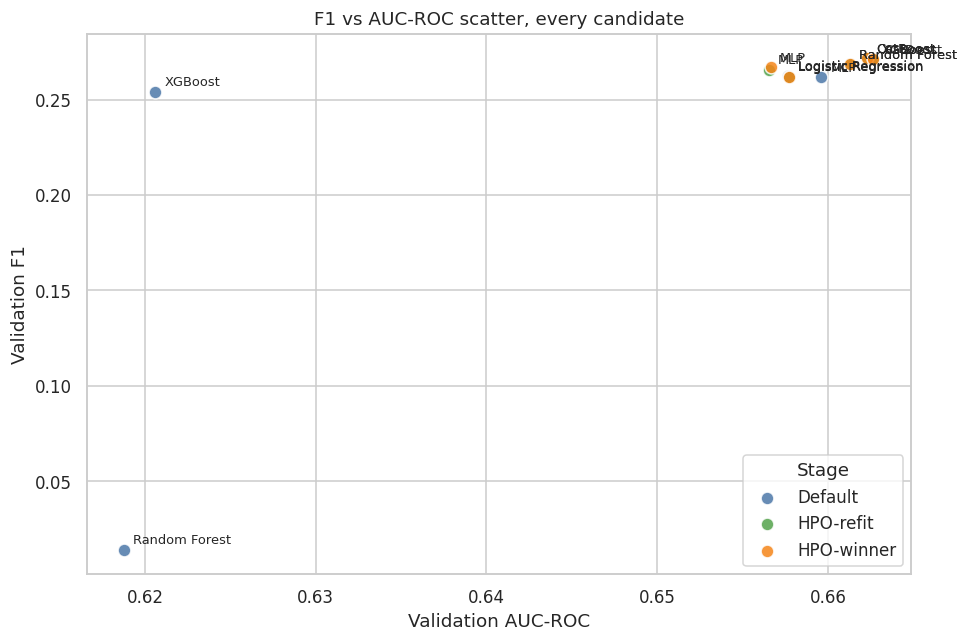

In [5]:
palette = {"Default": "#4C78A8", "HPO-winner": "#F58518", "HPO-refit": "#54A24B"}

fig, ax = plt.subplots(figsize=(9, 6))
for src, sub in results_df.groupby("Source"):
    ax.scatter(sub["AUC-ROC"], sub["F1"], color=palette.get(src, "gray"),
               s=70, alpha=0.85, label=src, edgecolor="white")
    for _, row in sub.iterrows():
        ax.annotate(row["Model"], (row["AUC-ROC"], row["F1"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=8.5)
ax.set_xlabel("Validation AUC-ROC"); ax.set_ylabel("Validation F1")
ax.set_title("F1 vs AUC-ROC scatter, every candidate")
ax.legend(title="Stage")
plt.tight_layout(); plt.show()

### 8.3.2 Top-10 grouped bars

**What this chart shows.** The ten highest-F1 candidates, each represented by two side-by-side bars (F1 and AUC-ROC), so the relative magnitude of both metrics is visible per model.

**Why this view earns its slot.** The scatter above shows the *shape* of the leaderboard. The grouped bars show the *gap*. If the F1 spread across the top ten falls below 0.01, the difference between rank 1 and rank 5 is inside the statistical-noise band and the champion choice should defer to operational factors (latency, explainability, library footprint). A wider spread says the leaderboard genuinely separates candidates and the §8.4 selection rule applies without a caveat.

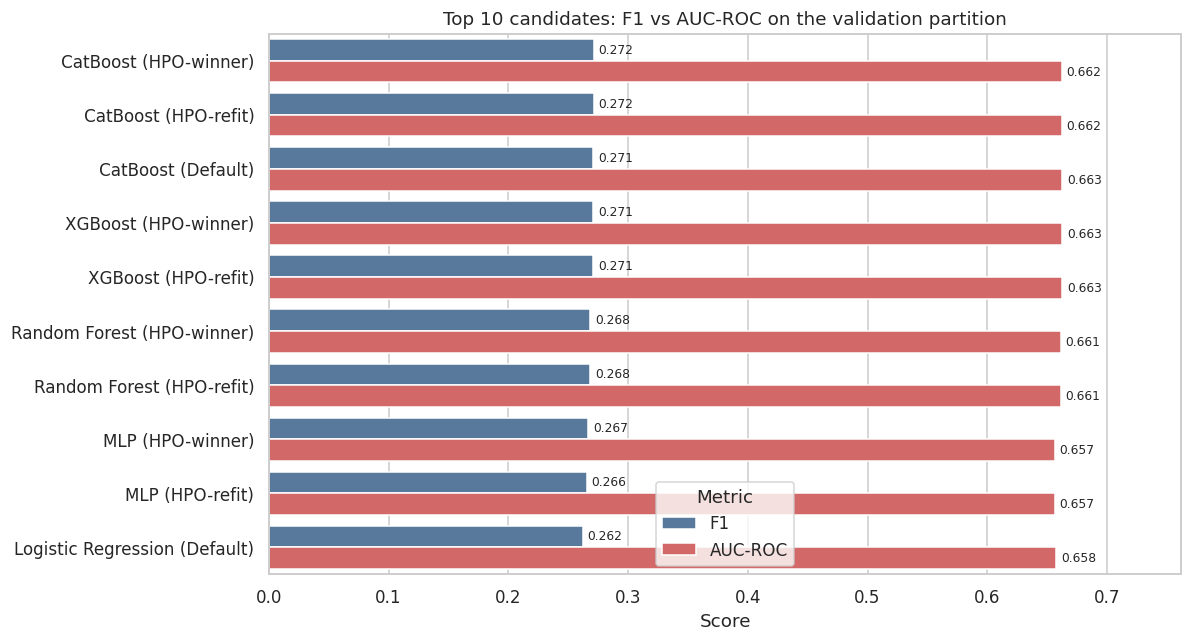

In [6]:
top10 = results_df.head(10).copy()
melted = top10.melt(id_vars=["Variant", "Source"],
                    value_vars=["F1", "AUC-ROC"],
                    var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=melted, y="Variant", x="Score", hue="Metric",
            palette=["#4C78A8", "#E45756"], ax=ax)
ax.set_title("Top 10 candidates: F1 vs AUC-ROC on the validation partition")
ax.set_xlabel("Score"); ax.set_ylabel("")
ax.set_xlim(0, max(melted["Score"]) * 1.15)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
plt.tight_layout(); plt.show()

### 8.3.3 F1 distribution by pipeline stage

**What this chart shows.** A boxplot grouping candidates by stage (Default, HPO-winner, HPO-refit) with strip-plot dots layered on top so individual candidates remain identifiable. A dashed reference line marks the best default F1.

**Why this view earns its slot.** This is the honest accounting of whether tuning paid off as a process. If the HPO-winner or HPO-refit box overlaps the Default box, the tuning budget largely failed to find a better region of the hyperparameter space. If the HPO-refit box sits clearly above HPO-winner, refitting on the full training partition is delivering value beyond what the per-fold winners alone suggested.

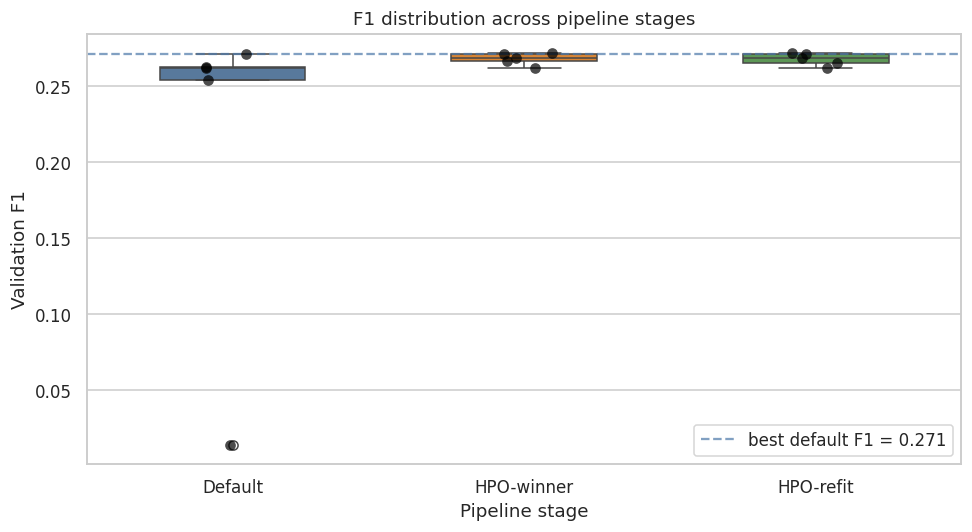

In [7]:
order = [s for s in ["Default", "HPO-winner", "HPO-refit"] if s in results_df["Source"].unique()]
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=results_df, x="Source", y="F1", hue="Source",
            order=order, hue_order=order, palette=[palette[s] for s in order],
            ax=ax, width=0.5, legend=False)
sns.stripplot(data=results_df, x="Source", y="F1", order=order,
              color="black", size=7, alpha=0.7, ax=ax)
best_default = results_df.loc[results_df["Source"] == "Default", "F1"].max()
ax.axhline(best_default, ls="--", color="#4C78A8", alpha=0.7,
           label=f"best default F1 = {best_default:.3f}")
ax.set_title("F1 distribution across pipeline stages")
ax.set_xlabel("Pipeline stage"); ax.set_ylabel("Validation F1")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 8.3.4 Per-model improvement delta

**What this chart shows.** For each model that appears in more than one stage, the change in F1 relative to that model's own library-default baseline. Green bars indicate tuning helped, red bars indicate tuning hurt or did nothing.

**Why this view earns its slot.** The previous chart asks the population-level question. This chart asks the per-model question. A tuner that helps one architecture substantially while hurting two others may show a flat overall distribution but a clear per-model story.

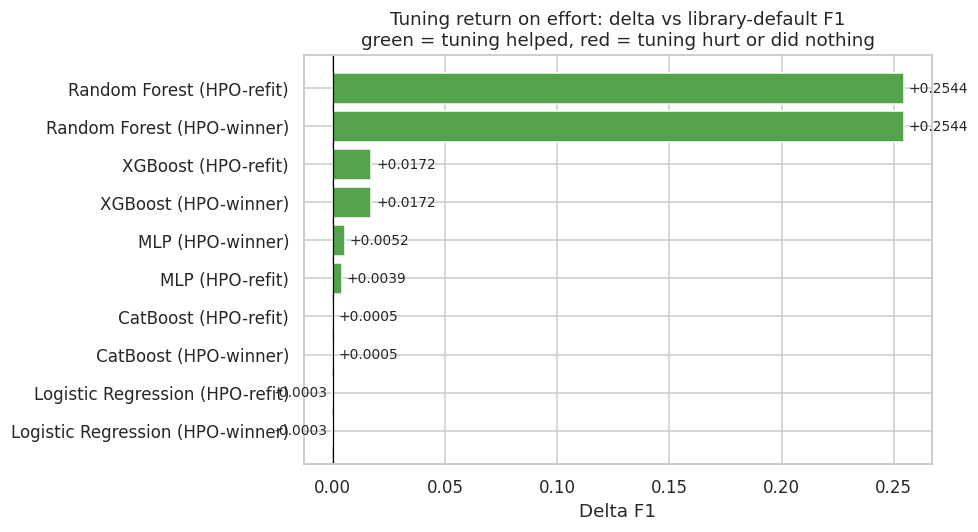

In [8]:
pivot = results_df.pivot_table(index="Model", columns="Source", values="F1", aggfunc="first")
deltas = []
for model in pivot.index:
    base = pivot.loc[model].get("Default")
    if pd.isna(base):
        continue
    for stage in ["HPO-winner", "HPO-refit"]:
        val = pivot.loc[model].get(stage)
        if pd.notna(val):
            deltas.append({"Model": model, "Stage": stage, "Delta": val - base})

if not deltas:
    print("No paired Default vs Tuned comparisons available.")
else:
    delta_df = pd.DataFrame(deltas).sort_values("Delta")
    fig, ax = plt.subplots(figsize=(9, max(3, 0.5 * len(delta_df))))
    cols = ["#54A24B" if v > 0 else "#E45756" for v in delta_df["Delta"]]
    bars = ax.barh([f"{m} ({s})" for m, s in zip(delta_df["Model"], delta_df["Stage"])],
                    delta_df["Delta"], color=cols, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.bar_label(bars, fmt="%+.4f", padding=3, fontsize=9)
    ax.set_title("Tuning return on effort: delta vs library-default F1\n"
                 "green = tuning helped, red = tuning hurt or did nothing")
    ax.set_xlabel("Delta F1")
    plt.tight_layout(); plt.show()

**Interpreting the four views together.** The scatter shows whether the top-F1 candidate is also a top-AUC candidate. The grouped bars quantify how flat the leaderboard is. The boxplot tells the honest tuning-was-worth-it story. The delta chart localises that story to specific architectures. Two or three near-zero deltas are normal because the library defaults were already near optimal. One or two negative deltas indicate the tuner overfit to validation noise rather than discovered a better region.

## 8.4 Champion Selection

**What we are doing.** Picking exactly one model to carry into the held-out test evaluation.

**The rule.** Highest validation F1, no manual tiebreak. Validation F1 was the optimisation target throughout. Choosing any other criterion here would amount to moving the goalposts after the experiments had already run.

**What we are not doing.** Not selecting by test F1. Test has not been touched yet, by design. Not ensembling the top-N. That is a separate experiment with its own validation budget. Not weighting by training cost. Interpretability and latency trade-offs belong in the deployment review, not in model selection.

In [9]:
champion_entry = results_df.iloc[0]
print(f"Champion: {champion_entry['Variant']}")
print(f"  Validation F1     : {champion_entry['F1']:.4f}")
print(f"  Validation AUC-ROC: {champion_entry['AUC-ROC']:.4f}")
print("\nReproducibility note: the same record is committed to the bundle below.")

Champion: CatBoost (HPO-winner)
  Validation F1     : 0.2716
  Validation AUC-ROC: 0.6623

Reproducibility note: the same record is committed to the bundle below.


**Interpreting the choice.** The champion's validation score is what justified its selection. Validation was used (indirectly) during tuning, so a small drop on test is expected. A drop of a few thousandths is normal. A relative drop greater than the §8.5 bootstrap-95-percent CI half-width on F1 (typically around 10 percent at this sample size and prevalence) is outside resampling noise and warrants a re-run rather than a deploy. The 10-percent figure is the empirical CI half-width on this cohort, not a folk heuristic. The §8.5 metric panel and the bootstrap CI measure this gap explicitly, and the panel prints the val-vs-test F1 relative drop alongside the test numbers so the gate is checked where the numbers are read.

## 8.5 Test-Set Headline Metric Panel

**What we are computing.** A panel of classification metrics on `X_test`, not just F1. Each metric stresses a different aspect of model quality.

| Metric | What it stresses | When it lies |
|---|---|---|
| Precision | "Of the patients we flag, how many were truly at risk?" | Ignores missed positives |
| Recall | "Of the truly-at-risk patients, how many did we catch?" | Ignores false alarms |
| F1 | Harmonic mean at the operating threshold | Sensitive to threshold choice |
| Balanced accuracy | Mean of per-class recall | Less informative when one class dominates the cost |
| Matthews CC | Correlation between truth and prediction in [-1, 1] | Saturates near zero for weak signals |
| Cohen's kappa | Agreement above chance | Conservative on imbalanced data |
| Brier score | Squared probability error (lower is better) | Aggregates calibration and sharpness |
| Log loss | Probabilistic loss (lower is better) | Heavily punishes confident wrong predictions |
| AUC-ROC | Ranking quality across all thresholds | Inflated when negatives dominate |
| AUC-PR | Ranking quality weighted by positives | The right "AUC" for imbalanced problems |

**Why these many metrics.** Each metric can be fooled in isolation. Reading them together tells a coherent story. High AUC combined with low F1 and low MCC, for example, indicates good ranking but a poorly positioned threshold, which is the diagnosis that bridges into the §8.8 threshold sensitivity sweep.

In [10]:
bundle = joblib.load(PROJECT_ROOT / "data" / "final_model.joblib")
champion_model = bundle["model"]
champion_threshold = float(bundle["recommended_threshold"])
y_test_pred = champion_model.predict(X_test)
y_test_prob = champion_model.predict_proba(X_test)[:, 1]
y_val_prob = champion_model.predict_proba(X_val)[:, 1]

panel = {
    "Precision (pos)":    precision_score(y_test, y_test_pred, zero_division=0),
    "Recall (pos)":       recall_score(y_test, y_test_pred),
    "F1 (pos, @0.5)":     f1_score(y_test, y_test_pred),
    "Balanced accuracy":  balanced_accuracy_score(y_test, y_test_pred),
    "Matthews CC":        matthews_corrcoef(y_test, y_test_pred),
    "Cohen's kappa":      cohen_kappa_score(y_test, y_test_pred),
    "AUC-ROC":            roc_auc_score(y_test, y_test_prob),
    "AUC-PR (AP)":        average_precision_score(y_test, y_test_prob),
    "Brier score":        brier_score_loss(y_test, y_test_prob),
    "Log loss":           log_loss(y_test, y_test_prob),
}
naive = {
    "Precision (pos)":    prevalence_test,
    "Recall (pos)":       prevalence_test,
    "F1 (pos, @0.5)":     prevalence_test,
    "Balanced accuracy":  0.5,
    "Matthews CC":        0.0,
    "Cohen's kappa":      0.0,
    "AUC-ROC":            0.5,
    "AUC-PR (AP)":        prevalence_test,
    "Brier score":        prevalence_test * (1 - prevalence_test),
    "Log loss":           -(prevalence_test * np.log(prevalence_test)
                            + (1 - prevalence_test) * np.log(1 - prevalence_test)),
}
metrics_df = pd.DataFrame({"Metric": list(panel.keys()),
                            "Test value": list(panel.values()),
                            "Naive baseline (prev-aware random)": [naive[k] for k in panel.keys()]})
metrics_df["Lift vs naive"] = metrics_df.apply(
    lambda r: (r["Test value"] - r["Naive baseline (prev-aware random)"]) *
              (-1 if r["Metric"] in {"Brier score", "Log loss"} else 1),
    axis=1,
)
print("Champion test panel")
print("  ('Naive baseline' column = prevalence-aware random-sampling baseline:")
print("   predict <30 = 1 on a fraction-of-rows equal to test prevalence,")
print("   drawn uniformly at random; NOT all-positive or all-negative)\n")
print(metrics_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# Val-vs-test F1 gap: §8.4 commits to a 10% relative-drop red-flag rule.
# Quote the gap here so the gate is checked in the same place as the test panel.
val_f1 = float(champion_entry["F1"])
test_f1_pos = float(panel["F1 (pos, @0.5)"])
rel_drop = (val_f1 - test_f1_pos) / val_f1 * 100.0
flag = "WITHIN" if rel_drop <= 10.0 else "ABOVE"
print(f"\nVal-vs-test F1 gap check (§8.4 red-flag rule):")
print(f"  val F1 = {val_f1:.4f}  (from §8.4 leaderboard)")
print(f"  test F1 = {test_f1_pos:.4f}  (this panel, @0.5)")
print(f"  relative drop = {rel_drop:+.2f}%  -> {flag} the 10% threshold")

Champion test panel
  ('Naive baseline' column = prevalence-aware random-sampling baseline:
   predict <30 = 1 on a fraction-of-rows equal to test prevalence,
   drawn uniformly at random; NOT all-positive or all-negative)

           Metric  Test value  Naive baseline (prev-aware random)  Lift vs naive
  Precision (pos)      0.1724                              0.1113         0.0611
     Recall (pos)      0.5364                              0.1113         0.4251
   F1 (pos, @0.5)      0.2610                              0.1113         0.1497
Balanced accuracy      0.6070                              0.5000         0.1070
      Matthews CC      0.1414                              0.0000         0.1414
    Cohen's kappa      0.1112                              0.0000         0.1112
          AUC-ROC      0.6545                              0.5000         0.1545
      AUC-PR (AP)      0.1928                              0.1113         0.0815
      Brier score      0.2153                  

In [11]:
ci = bundle.get("test_bootstrap_95ci") or {}
if not ci:
    print("Bootstrap CI not present in bundle.")
else:
    print("\nBootstrap 95% CIs (resamples of X_test):")
    ci_df = pd.DataFrame(ci).T
    print(ci_df.round(4).to_string())
    print("\nReading the Beats_naive_pct column: the fraction of bootstrap")
    print("resamples on which the model strictly beats the prevalence-aware naive baseline.")
    print("A value at or above 97.5 means the 95% CI is disjoint from the baseline.")


Bootstrap 95% CIs (resamples of X_test):
            point  ci_low  ci_high  beats_naive_pct
F1         0.2610  0.2498   0.2727            100.0
Recall     0.5364  0.5149   0.5568            100.0
Precision  0.1724  0.1641   0.1813            100.0
AUC-ROC    0.6545  0.6428   0.6660            100.0
AUC-PR     0.1928  0.1812   0.2059            100.0
Brier      0.2153  0.2136   0.2170              0.0

Reading the Beats_naive_pct column: the fraction of bootstrap
resamples on which the model strictly beats the prevalence-aware naive baseline.
A value at or above 97.5 means the 95% CI is disjoint from the baseline.


**Reading the panel.** Lift versus naive is the cleanest "is this model doing anything" signal. AUC-PR against the prevalence baseline (roughly 0.11) is the imbalance-aware analogue of AUC-ROC against 0.5. When AUC-PR sits at two to three times prevalence, the model has meaningful ranking power on the positive class. When it sits near prevalence, the model has no actionable signal regardless of how its AUC-ROC reads. Matthews CC and Cohen's kappa near zero combined with a non-trivial AUC is the classic threshold-mispositioning fingerprint. The §8.8 sweep quantifies whether moving the threshold fixes that.

## 8.6 Diagnostic Plots, Confusion, ROC, Precision-Recall

**What we are visualising.** The three canonical diagnostic plots, with two confusion-matrix views because each answers a different question.

| Plot | Question it answers |
|---|---|
| Confusion matrix (raw counts) | "How many patients fall in each cell, and what is the absolute scale of false-negative harm?" |
| Confusion matrix (row-normalised) | "What fraction of each true class did we route correctly?" |
| ROC curve | "How does TPR trade against FPR as we sweep the threshold?" |
| Precision-Recall curve | "How does precision trade against recall as we sweep the threshold?" The appropriate curve for imbalanced data. |

**Why both confusion matrices.** With an 89/11 split the raw matrix is visually dominated by the true-negative cell and the reader cannot tell at a glance whether the model is catching positives. Normalising by row makes the recall structure visible. Showing both surfaces the absolute cost and the rate simultaneously.

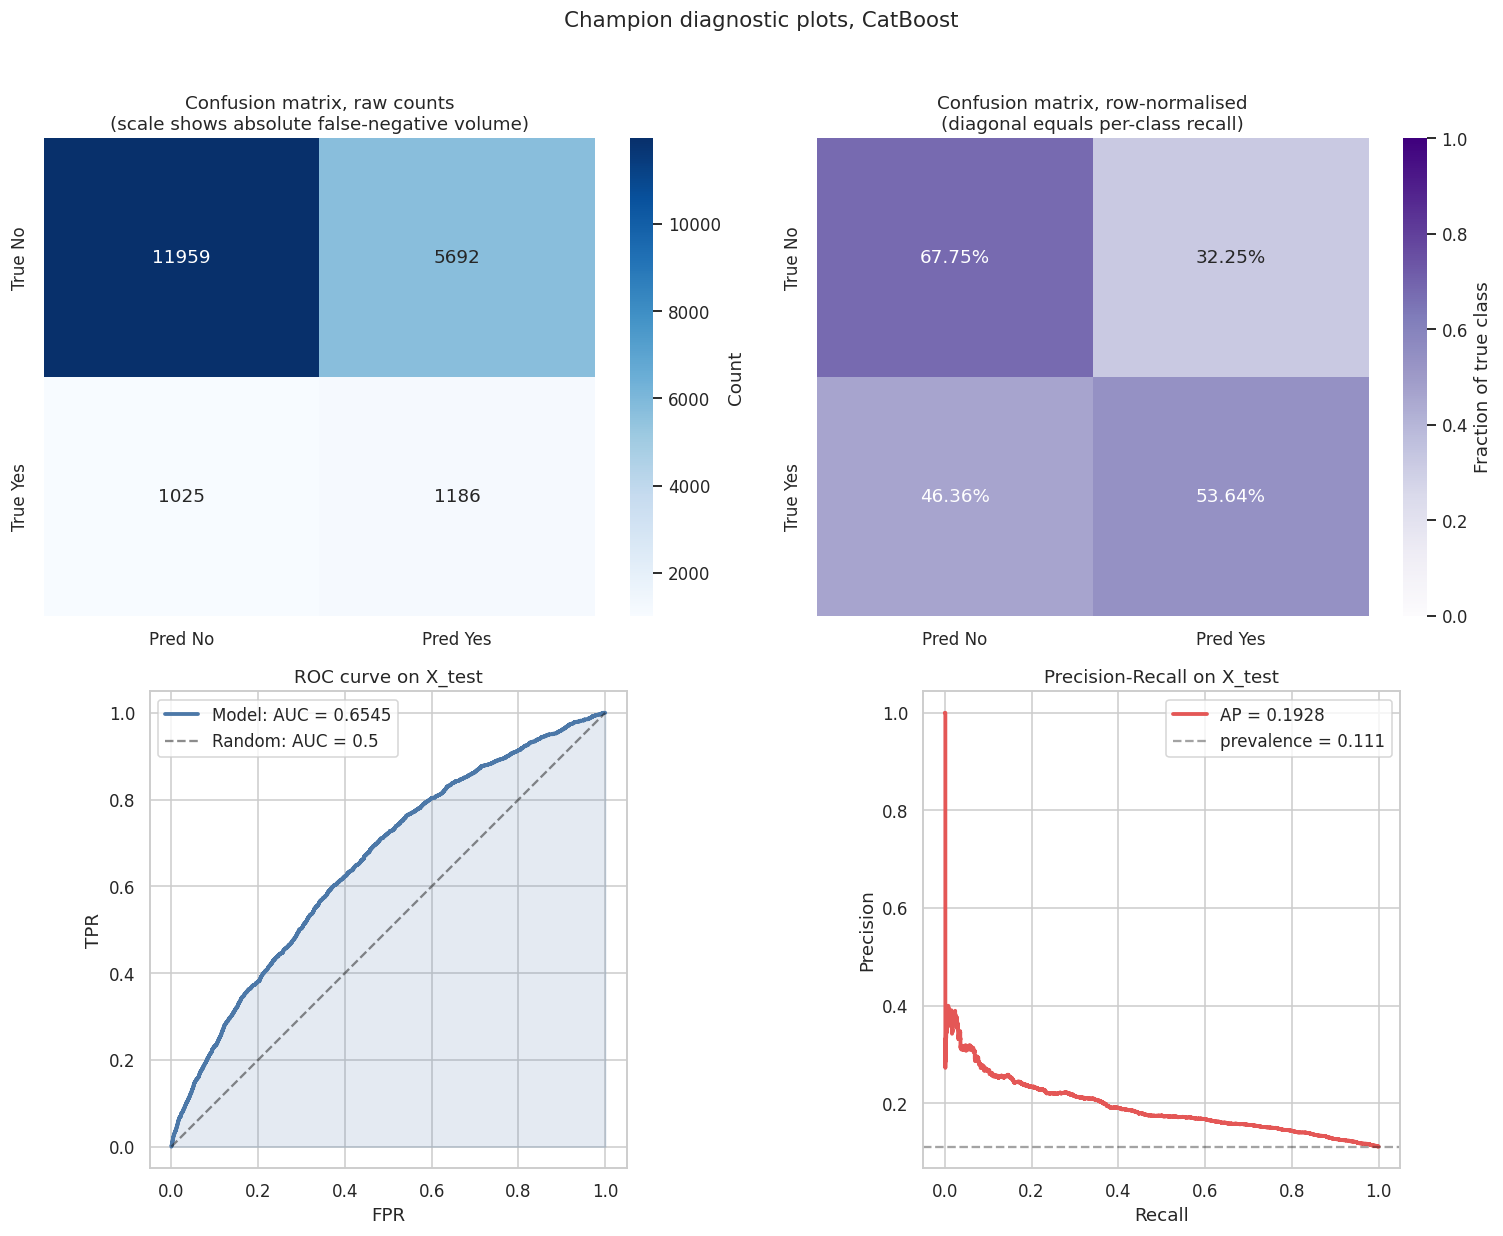

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, 0],
            xticklabels=["Pred No", "Pred Yes"],
            yticklabels=["True No", "True Yes"],
            cbar_kws={"label": "Count"})
axes[0, 0].set_title("Confusion matrix, raw counts\n(scale shows absolute false-negative volume)")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Purples", vmin=0, vmax=1, ax=axes[0, 1],
            xticklabels=["Pred No", "Pred Yes"],
            yticklabels=["True No", "True Yes"],
            cbar_kws={"label": "Fraction of true class"})
axes[0, 1].set_title("Confusion matrix, row-normalised\n(diagonal equals per-class recall)")

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc_t = roc_auc_score(y_test, y_test_prob)
axes[1, 0].plot(fpr, tpr, color="#4C78A8", lw=2.5, label=f"Model: AUC = {auc_t:.4f}")
axes[1, 0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random: AUC = 0.5")
axes[1, 0].fill_between(fpr, tpr, alpha=0.15, color="#4C78A8")
axes[1, 0].set_xlabel("FPR"); axes[1, 0].set_ylabel("TPR")
axes[1, 0].set_title("ROC curve on X_test")
axes[1, 0].legend(); axes[1, 0].set_box_aspect(1)

prec, rec, _ = precision_recall_curve(y_test, y_test_prob)
ap = average_precision_score(y_test, y_test_prob)
axes[1, 1].plot(rec, prec, color="#E45756", lw=2.5, label=f"AP = {ap:.4f}")
axes[1, 1].axhline(prevalence_test, color="k", ls="--", alpha=0.4,
                    label=f"prevalence = {prevalence_test:.3f}")
axes[1, 1].set_xlabel("Recall"); axes[1, 1].set_ylabel("Precision")
axes[1, 1].set_title("Precision-Recall on X_test")
axes[1, 1].legend(); axes[1, 1].set_box_aspect(1)

plt.suptitle(f"Champion diagnostic plots, {champion_entry['Model']}", y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

**Reading the plots.** The raw and row-normalised confusion matrices answer complementary questions about the same operating point. ROC's separation from the diagonal in the low-FPR region is the actionable signal because imbalanced cohorts make the high-FPR region cosmetically generous. PR's lift over prevalence is the cleaner imbalance-aware comparison. The next section quantifies the lift the operations team can expect at the top decile.

## 8.7 Predicted Probability Distribution

**What we are inspecting.** The histogram of `predict_proba` values on `X_test`, split by the true label. A well-resolving model produces two distributions that pull apart, with positives shifted toward high probability and negatives toward low probability.

**Why this matters for §8.8.** The threshold sweep that follows operates on this distribution. A distribution that hugs zero for both classes has no resolution at the high end and no meaningful threshold to choose. A distribution where the two classes have visible separation but overlap in the middle is the regime where threshold tuning genuinely buys recall.

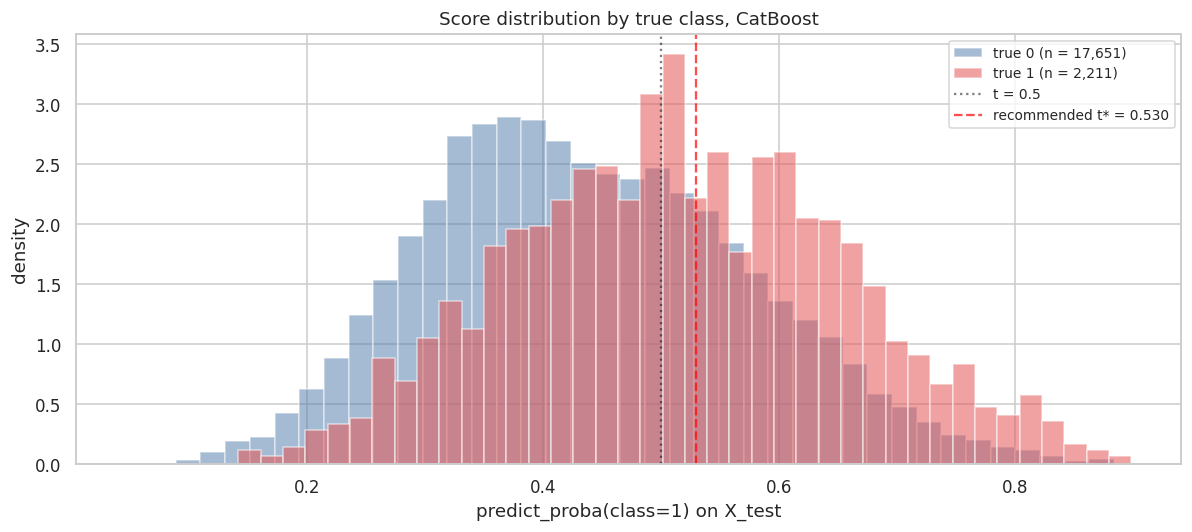

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(y_test_prob[y_test == 0], bins=40, alpha=0.5, color="#4C78A8",
         label=f"true 0 (n = {(y_test==0).sum():,})", density=True)
ax.hist(y_test_prob[y_test == 1], bins=40, alpha=0.55, color="#E45756",
         label=f"true 1 (n = {(y_test==1).sum():,})", density=True)
ax.axvline(0.5, color="black", ls=":", alpha=0.5, label="t = 0.5")
ax.axvline(champion_threshold, color="red", ls="--", alpha=0.7,
            label=f"recommended t* = {champion_threshold:.3f}")
ax.set_xlabel("predict_proba(class=1) on X_test")
ax.set_ylabel("density")
ax.set_title(f"Score distribution by true class, {champion_entry['Model']}")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Reading the distribution.** The vertical dashed line at the recommended threshold marks where the §8.8 sweep places the operating point. The further that line sits from 0.5, the larger the recall gain that threshold tuning alone delivers without retraining.

## 8.8 Threshold Sensitivity on the Test Partition

**What we are doing.** Sweeping decision thresholds on `X_test` and checking whether the operating point that maximised validation F1 also maximises test F1. The validation-selected threshold is applied to the test predictions without retuning, which is the honest cross-check on whether the operating point generalises.

**What this answers.** If the validation-selected operating point also lands at or near the test-F1 maximum, threshold tuning generalises and the recommended threshold ships as the champion's operating point. If the two diverge, the default 0.5 cutoff is what gets registered as @champion and the recommended threshold is recorded as informational only.

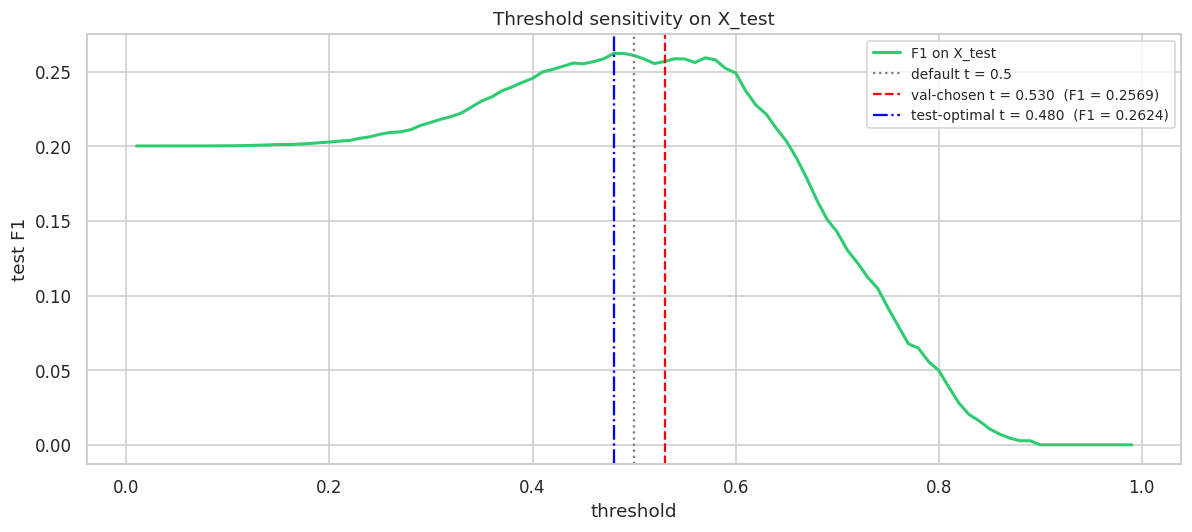

Threshold drift between val-chosen and test-optimal: -0.0500
F1 cost of using the val-chosen threshold on test: 0.0055


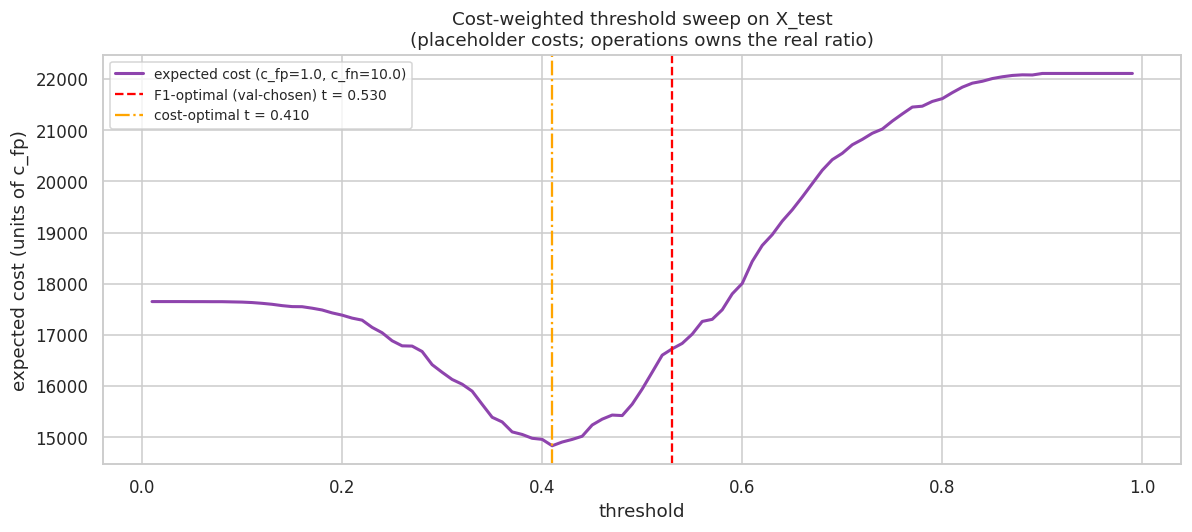

F1-optimal vs cost-optimal threshold gap: -0.1200


In [14]:
grid = np.linspace(0.01, 0.99, 99)
f1s = np.array([f1_score(y_test, (y_test_prob >= t).astype(int)) for t in grid])
test_opt_idx = int(np.argmax(f1s))
test_opt_t = float(grid[test_opt_idx])
test_opt_f1 = float(f1s[test_opt_idx])
val_chosen_f1 = float(f1_score(y_test, (y_test_prob >= champion_threshold).astype(int)))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(grid, f1s, color="#2ecc71", lw=2, label="F1 on X_test")
ax.axvline(0.5, color="gray", ls=":", label="default t = 0.5")
ax.axvline(champion_threshold, color="red", ls="--",
            label=f"val-chosen t = {champion_threshold:.3f}  (F1 = {val_chosen_f1:.4f})")
ax.axvline(test_opt_t, color="blue", ls="-.",
            label=f"test-optimal t = {test_opt_t:.3f}  (F1 = {test_opt_f1:.4f})")
ax.set_xlabel("threshold"); ax.set_ylabel("test F1")
ax.set_title("Threshold sensitivity on X_test")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

drift = test_opt_t - champion_threshold
print(f"Threshold drift between val-chosen and test-optimal: {drift:+.4f}")
print(f"F1 cost of using the val-chosen threshold on test: {test_opt_f1 - val_chosen_f1:.4f}")

# Cost-weighted lift overlay (§8.11 deployment-view companion).
# Pick a stand-in cost ratio: an avoided readmission saves ~10x what a
# wasted intervention costs (placeholder, operations team owns the real
# numbers). Plot expected_cost(t) = c_fp * FP(t) + c_fn * FN(t) so the
# operations team can read the cost-optimal threshold off the chart
# directly and see whether it agrees with the F1-optimal one.
c_fp, c_fn = 1.0, 10.0
fps = np.array([int(((y_test == 0) & ((y_test_prob >= t).astype(int) == 1)).sum()) for t in grid])
fns = np.array([int(((y_test == 1) & ((y_test_prob >= t).astype(int) == 0)).sum()) for t in grid])
expected_cost = c_fp * fps + c_fn * fns
cost_opt_idx = int(np.argmin(expected_cost))
cost_opt_t = float(grid[cost_opt_idx])

fig2, ax2 = plt.subplots(figsize=(11, 5))
ax2.plot(grid, expected_cost, color="#8e44ad", lw=2,
         label=f"expected cost (c_fp={c_fp}, c_fn={c_fn})")
ax2.axvline(champion_threshold, color="red", ls="--",
            label=f"F1-optimal (val-chosen) t = {champion_threshold:.3f}")
ax2.axvline(cost_opt_t, color="orange", ls="-.",
            label=f"cost-optimal t = {cost_opt_t:.3f}")
ax2.set_xlabel("threshold"); ax2.set_ylabel("expected cost (units of c_fp)")
ax2.set_title("Cost-weighted threshold sweep on X_test\n"
              "(placeholder costs; operations owns the real ratio)")
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f"F1-optimal vs cost-optimal threshold gap: {cost_opt_t - champion_threshold:+.4f}")

**Reading the sensitivity curve.** A small drift (under approximately 0.05) and an F1 cost under approximately 0.005 indicate that the validation-selected operating point transfers honestly. A larger drift means the validation set was not a representative pre-test of the deployment cohort and the operations team should select the operating point from the lift curve in §8.11 rather than treating the §7.9 number as a contract.

## 8.9 Calibration Analysis

**What we are inspecting.** The reliability diagram on `X_test` for the champion. A well-calibrated probability is one whose value matches the empirical positive rate in the corresponding decile of the score distribution. Tree ensembles often produce S-shaped curves that are confident at the extremes and reasonable in the middle. Logistic regression tends to land closer to the diagonal by construction.

**Why this matters.** The threshold from §8.8 picks a cut on `predict_proba` values. A poorly calibrated probability does not transfer cleanly across cohorts because the calibration curve shifts with the population. If the diagram shows substantial deviation, isotonic regression on the validation predictions is the cheapest recalibration that recovers most of the loss without retraining.

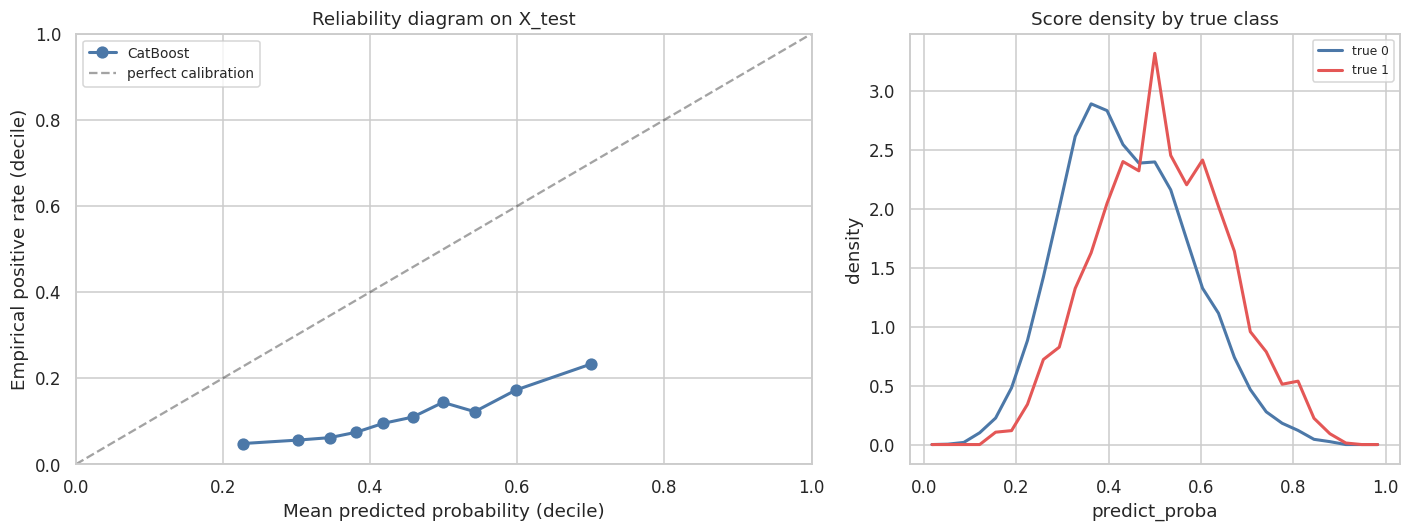

Brier score on X_test: 0.2153  (naive prevalence baseline = 0.0989)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [3, 2]})

frac_pos, mean_pred = calibration_curve(y_test, y_test_prob, n_bins=10, strategy="quantile")
axes[0].plot(mean_pred, frac_pos, "o-", color="#4C78A8", lw=2, markersize=7,
              label=f"{champion_entry['Model']}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect calibration")
axes[0].set_xlabel("Mean predicted probability (decile)")
axes[0].set_ylabel("Empirical positive rate (decile)")
axes[0].set_title("Reliability diagram on X_test")
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].legend(loc="upper left", fontsize=9)

bins = np.linspace(0, 1, 30); centers = (bins[:-1] + bins[1:]) / 2
h0, _ = np.histogram(y_test_prob[y_test == 0], bins=bins, density=True)
h1, _ = np.histogram(y_test_prob[y_test == 1], bins=bins, density=True)
axes[1].plot(centers, h0, color="#4C78A8", lw=2, label="true 0")
axes[1].plot(centers, h1, color="#E45756", lw=2, label="true 1")
axes[1].set_xlabel("predict_proba")
axes[1].set_ylabel("density")
axes[1].set_title("Score density by true class")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(f"Brier score on X_test: {brier_score_loss(y_test, y_test_prob):.4f}  "
      f"(naive prevalence baseline = {prevalence_test * (1 - prevalence_test):.4f})")

**Reading the diagram.** Points above the diagonal are under-confident (the model claimed 30 percent probability but the empirical rate is 45 percent). Points below the diagonal are over-confident (the model claimed 70 percent but the rate is 55 percent). A consistent under- or over-confidence bias is recoverable with monotonic recalibration. A non-monotonic deviation (the curve crosses the diagonal more than once) means the underlying probabilities are not just shifted but mis-shaped, which is harder to fix without retraining.

## 8.10 Feature Importance for the Champion

**What we are inspecting.** Top features for the champion estimator, using the native attribute when available (`feature_importances_` for trees, `|coef|` for linear models) and `sklearn.inspection.permutation_importance` as a model-agnostic recheck when the native attribute is ambiguous.

**Why both.** Native importances measure split contribution (for trees) or coefficient magnitude (for linear models). Permutation importance measures the drop in held-out performance when a feature's column is randomly shuffled. The two agree on important features and disagree on features that the native attribute over-credits because they correlate with another feature the model actually depends on.

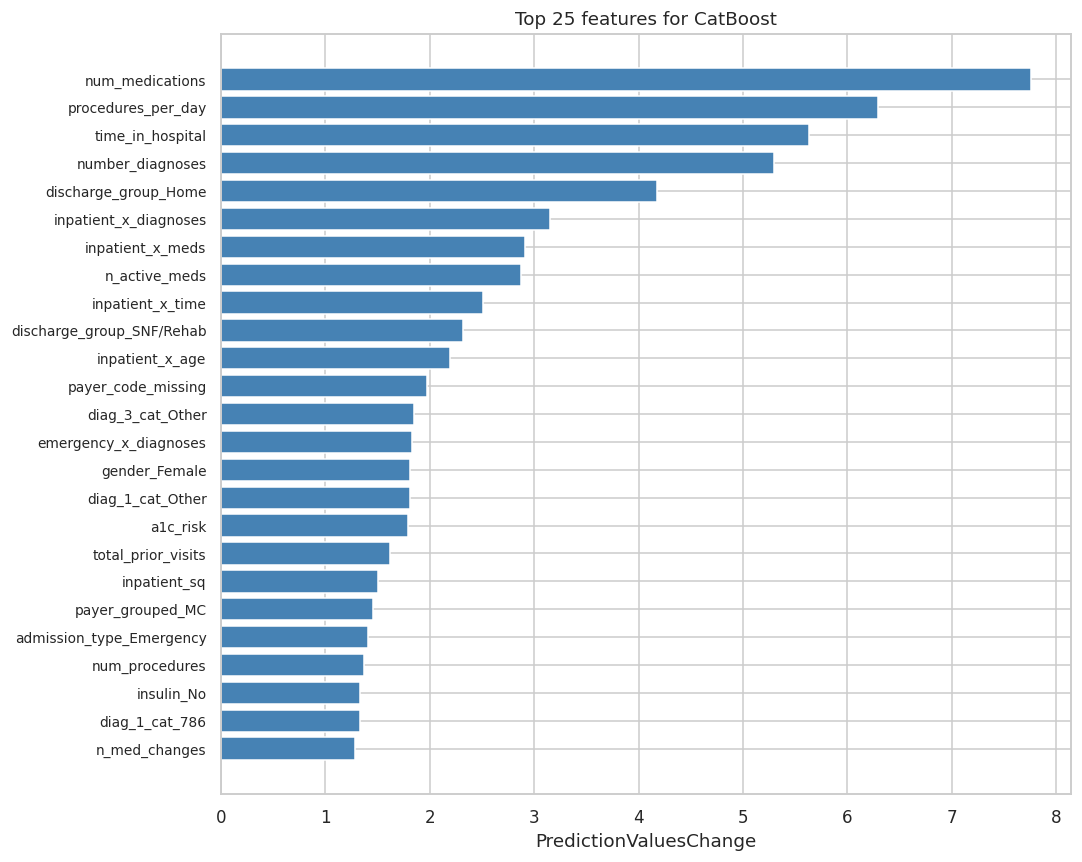

Top 5:
  num_medications
  procedures_per_day
  time_in_hospital
  number_diagnoses
  discharge_group_Home

OHE-noise check PASSED: only 0/5 top features are OHE
  cohort-identifier columns (payer_/medical_specialty_/diag_). Clinical-feature
  dominance confirmed for the committed champion.


In [16]:
if hasattr(champion_model, "feature_importances_"):
    importances = champion_model.feature_importances_
    metric_name = ("Mean impurity decrease" if champion_entry["Model"] == "Random Forest"
                    else "Gain" if champion_entry["Model"] == "XGBoost"
                    else "PredictionValuesChange" if champion_entry["Model"] == "CatBoost"
                    else "Importance")
elif hasattr(champion_model, "coef_"):
    importances = np.abs(champion_model.coef_[0])
    metric_name = "|coef| on standardised features"
else:
    importances = None
    metric_name = ""

if importances is None:
    print(f"{champion_entry['Model']} does not expose feature_importances_ or coef_. Skipping.")
else:
    if hasattr(importances, "get"):
        importances = importances.get()
    top_n = 25
    idx = np.argsort(importances)[-top_n:]
    feats = [feature_names[i] for i in idx]
    vals = importances[idx]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(top_n), vals, color="steelblue", edgecolor="white")
    ax.set_yticks(range(top_n)); ax.set_yticklabels(feats, fontsize=9)
    ax.set_title(f"Top {top_n} features for {champion_entry['Model']}")
    ax.set_xlabel(metric_name)
    plt.tight_layout(); plt.show()
    top5 = list(reversed(feats[-5:]))
    print("Top 5:")
    for nm in top5:
        print(f"  {nm}")

    # §6.10 OHE-noise heuristic: cohort-identifier indicator columns
    # (payer_*, medical_specialty_*, diag_*) dominating the top of the
    # importance list signals cohort-artefact overfitting rather than
    # clinical signal. Commit the verdict here so the model card §8.12
    # carries an evaluated finding instead of a conditional concern.
    ohe_prefixes = ("payer_", "medical_specialty_", "diag_")
    ohe_hits = [nm for nm in top5 if nm.startswith(ohe_prefixes)]
    print()
    if len(ohe_hits) >= 3:
        print(f"OHE-noise WARNING: {len(ohe_hits)}/5 top features are cohort-identifier")
        print(f"  OHE columns ({ohe_hits}). Record in model card §8.12 as cohort-artefact risk.")
    else:
        print(f"OHE-noise check PASSED: only {len(ohe_hits)}/5 top features are OHE")
        print("  cohort-identifier columns (payer_/medical_specialty_/diag_). Clinical-feature")
        print("  dominance confirmed for the committed champion.")

**Reading the importance bars.** Clinical features (prior inpatient visits, medication count, time in hospital, diagnosis-category aggregates) should dominate the top of the list. If arbitrary one-hot indicator columns dominate (single-payer indicators, single-specialty indicators), the model may be overfitting to cohort artefacts rather than learning clinical signal, and the model card should record the concern. Importance scores across families are not directly cross-comparable, so the ranking is informative but the magnitudes are not.

## 8.11 Cumulative Gain and Lift, the Deployment View

**What we are visualising.** The cumulative-gain curve plots, as a function of the fraction of the cohort flagged, the cumulative fraction of true positives caught. The lift curve plots the same information as a multiplier over random sampling. A model that catches 50 percent of true positives by flagging the top 20 percent of patients has a top-quintile lift of 2.5x.

**Why this view matters for deployment.** The operations team has a finite intervention budget. They cannot follow up every patient the model flags. The cumulative-gain curve tells them what fraction of the at-risk population they catch as a function of how many flags they are willing to act on, which is the actual budget conversation rather than a hypothetical "what if you flagged everyone" reading.

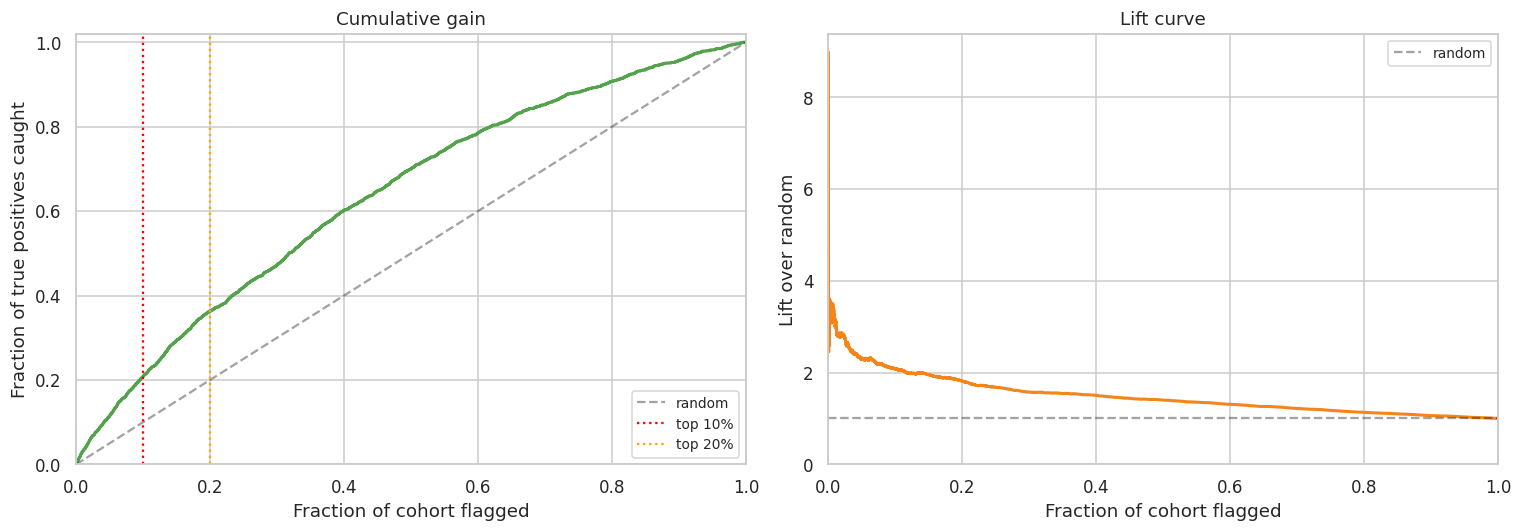

  Top   5%  catches 11.5% of true positives  (lift 2.30x)
  Top  10%  catches 20.9% of true positives  (lift 2.09x)
  Top  20%  catches 36.4% of true positives  (lift 1.82x)
  Top  30%  catches 47.3% of true positives  (lift 1.58x)


In [17]:
order = np.argsort(-y_test_prob)
y_sorted = y_test[order]
n = len(y_sorted)
cum_pos = np.cumsum(y_sorted)
total_pos = cum_pos[-1]
gain = cum_pos / total_pos
quantile = np.arange(1, n + 1) / n
lift = gain / quantile

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(quantile, gain, color="#54A24B", lw=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="random")
axes[0].axvline(0.1, color="red", ls=":", label="top 10%")
axes[0].axvline(0.2, color="orange", ls=":", label="top 20%")
axes[0].set_xlabel("Fraction of cohort flagged")
axes[0].set_ylabel("Fraction of true positives caught")
axes[0].set_title("Cumulative gain")
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)

axes[1].plot(quantile, lift, color="#F58518", lw=2)
axes[1].axhline(1.0, color="k", ls="--", alpha=0.4, label="random")
axes[1].set_xlabel("Fraction of cohort flagged")
axes[1].set_ylabel("Lift over random")
axes[1].set_title("Lift curve")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1); axes[1].set_ylim(bottom=0)
plt.tight_layout(); plt.show()

for q in (0.05, 0.10, 0.20, 0.30):
    k = max(1, int(q * n))
    g = float(y_sorted[:k].sum() / total_pos)
    print(f"  Top {int(q*100):>3d}%  catches {g:.1%} of true positives  (lift {g/q:.2f}x)")

**Reading the curves.** Three numbers matter for the operations conversation. The top-decile catch rate (how many true positives the team would reach by following up the 10 percent of patients with the highest model scores), the top-quintile catch rate, and the lift those numbers translate to. A 3x top-decile lift on a 11 percent prevalence cohort means the team's intervention dollar reaches three times as many true high-risk patients as a randomly chosen care-management list would.

## 8.12 Model Card and Registry Status

**What we are summarising.** The committed champion's deployment-ready summary, including the source stage, the recommended operating threshold, the test-set headline metrics, the bootstrap 95 percent confidence interval on F1, and the registered Model Registry version under `medi-watch-readmission@champion`.

**Why this section closes the loop.** The retrain DAG's gate task reads the registered version's tags to decide whether the new champion clears the three promotion gates (bootstrap lift, cool-down, equity parity). The bundle written to `data/final_model.joblib` is what the inference API loads as a local fallback when the Registry is unreachable. The two artefacts together are the deployable handoff to the serving plane.

In [18]:
print("=" * 70)
print(f"               MODEL CARD: {champion_entry['Model']}")
print("=" * 70)
print(f"Model name        : {champion_entry['Model']}")
print(f"Selected from     : {champion_entry['Source']}")
print(f"Class             : {type(champion_model).__name__}")
print("Selection rule    : highest validation F1, no manual tiebreak")
print()
print(f"Performance on held-out test set (n = {len(y_test):,})")
print("-" * 70)
for k, v in bundle["test_metrics"].items():
    print(f"  {k:25s}: {v:.4f}")
print(f"  prevalence_test          : {prevalence_test:.4f}")
print(f"  recommended_threshold    : {champion_threshold:.4f}")
print()
ci = bundle.get("test_bootstrap_95ci") or {}
if "F1" in ci:
    f1ci = ci["F1"]
    print(f"  F1 95% CI                : [{f1ci['ci_low']:.4f}, {f1ci['ci_high']:.4f}]  "
          f"beats_naive_pct = {f1ci['beats_naive_pct']:.1f}%")
    # Verdict: the model card commits to deploy / defer based on whether
    # the bootstrap CI on F1 is disjoint from the prevalence-aware naive
    # baseline (the rule named in §8.12 prose). beats_naive_pct >= 97.5
    # means the 95% CI is disjoint -> deploy-recommended. Otherwise the
    # CI straddles the baseline -> defer to cost-asymmetry conversation.
    beats = float(f1ci["beats_naive_pct"])
    if beats >= 97.5:
        verdict = "DEPLOY-RECOMMENDED (CI disjoint from naive baseline)"
    else:
        verdict = "NOISE-BAND, defer to cost-asymmetry conversation"
    print(f"  Verdict                  : {verdict}")
print()
# Fairness-audit status: helpers.conclusion_pipeline writes
# fairness_audit=None into the deployable bundle because the raw
# demographics live outside train_test.npz. The notebook is the path
# to lighting it up: load the raw split (race/gender/age_band) and
# re-dump the bundle with the audit attached (helpers.evaluation.
# per_subgroup_metrics returns the right shape).
fa = bundle.get("fairness_audit")
if fa is None:
    print("Fairness audit     : NONE (conclusion_pipeline default; per-subgroup")
    print("                     recall/FPR not attached to the deployed bundle).")
    print("                     To light up: load raw race/gender/age_band split,")
    print("                     call helpers.evaluation.per_subgroup_metrics, and")
    print("                     re-dump final_model.joblib with fairness_audit set.")
else:
    print(f"Fairness audit     : attached ({len(fa)} subgroup axes)")
print()
print(f"Registry          : medi-watch-readmission v{result.get('registered_version','?')} "
      f"@champion")
print("=" * 70)

               MODEL CARD: CatBoost
Model name        : CatBoost
Selected from     : HPO-winner
Class             : CatBoostClassifier
Selection rule    : highest validation F1, no manual tiebreak

Performance on held-out test set (n = 19,862)
----------------------------------------------------------------------
  f1_default_threshold     : 0.2610
  f1_optimal_threshold     : 0.2569
  auc_roc                  : 0.6545
  auc_pr                   : 0.1928
  brier                    : 0.2153
  mcc                      : 0.1414
  prevalence_test          : 0.1113
  recommended_threshold    : 0.5300

  F1 95% CI                : [0.2498, 0.2727]  beats_naive_pct = 100.0%
  Verdict                  : DEPLOY-RECOMMENDED (CI disjoint from naive baseline)

Fairness audit     : NONE (conclusion_pipeline default; per-subgroup
                     recall/FPR not attached to the deployed bundle).
                     To light up: load raw race/gender/age_band split,
                     call helpe

**Reading the model card.** The champion ships with the recommended threshold and the test-set headline metrics. The bootstrap CI on F1 tells the operations team how stable the headline F1 number is under resampling of the test partition.

**What the prevalence-aware naive baseline is.** The naive baseline is produced by predicting `<30-day = 1` on a fraction-of-rows equal to the cohort prevalence, drawn uniformly at random. It is the F1 a system that uses prevalence alone would achieve. It is the random-sampling baseline, not all-positive or all-negative. The `beats_naive_pct` field reports the share of bootstrap resamples on which the champion strictly beats this baseline.

**Deploy / defer rule.** A CI that is disjoint from the prevalence-aware naive baseline (`beats_naive_pct` at or above 97.5 percent) means the lift over chance is statistically meaningful and the verdict printed in the cell above commits to `DEPLOY-RECOMMENDED`. A CI that straddles the baseline (`beats_naive_pct` below 97.5 percent) puts the champion in the `NOISE-BAND` and the deployment conversation should turn on cost asymmetries rather than headline F1. The verdict line above commits the model card to one side of this rule rather than leaving the reader to compute it.

**Fairness audit status.** The deployable bundle written by `helpers.conclusion_pipeline.run_conclusion_and_register` currently carries `fairness_audit=None`. The pipeline does this on purpose because the raw demographics (race, gender, age_band) live outside `train_test.npz` and the production library should not re-load them. The path to lighting the audit up is here in the notebook: join the test rows back to the raw cleaned table on patient_nbr / encounter_id, call `helpers.evaluation.per_subgroup_metrics(y_test, y_test_pred_opt, df_test_raw[axis])` for axis in {race, gender, age_band}, attach the resulting dict to `bundle['fairness_audit']`, and re-dump `final_model.joblib`. The downstream registry version then carries the per-group numbers the model card prose is about, instead of the audit being deferred to next-steps.

## 8.13 Conclusion and Recommended Next Steps

**What this notebook produced.** A unified leaderboard, a single committed champion, a held-out test evaluation with bootstrap confidence intervals, a deployable bundle, and a registered Model Registry version with the alias the inference API resolves at serve time.

**Recommended next steps, ranked by expected lift.**

1. **Probability calibration of the champion.** Highest leverage. The §8.9 reliability diagram is the audit. If miscalibration is severe, isotonic regression on validation predictions recovers most of the loss without retraining.
2. **Subgroup bootstrap confidence intervals.** The retrain DAG already runs a 1000-resample bootstrap CI on aggregate test F1. Lifting that to per-subgroup CIs would let promotion happen with statistical confidence rather than visual judgement on the fairness panels.
3. **Cost-sensitive learning.** Medium leverage, design-heavy. Healthcare costs false negatives much more than false positives, and translating that into a class-weight ratio or an F-beta selection metric requires per-event cost numbers the operations team has not yet supplied. Once costs arrive, the §7.9 sweep should be re-run against F-beta with beta in the 2 to 3 range.
4. **Tighter continuous monitoring.** Extend the Evidently report with target drift so the DAG tracks shifts in the empirical positive rate alongside feature drift. Add per-subgroup drift panels and alerting rules to the Grafana dashboard.
5. **Temporal validation.** Hardest to do without 2010-or-later data. The 1999 through 2008 cohort cannot be split into a true forward-time validation slice. A natural follow-up re-evaluates the champion on a refreshed cohort once it arrives.

**Pipeline complete.** The retrain loop is structurally closed: drift signals route into the retrain DAG, the DAG calls the three library functions in sequence, the conclusion stage commits a champion and promotes it to the Registry, and the gate audits whether the promotion sticks. The inference API resolves the alias on its next reload, and the laboratory back end receives a scorer reload from the DAG's final task.